<a href="https://colab.research.google.com/github/alitourani/vision-paper-hub/blob/main/categories/depth-estimator/depth-pro/depth-pro-applications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **👁️‍🗨️ Vision Paper Hub** / **Depth Estimation** / **Depth Pro (Apple AI)**

This colaboratory is made to assess the quality of the **Depth Pro** library for absolute depth estimation.

- 🚀 [Benchmark](https://github.com/alitourani/vision-paper-hub/tree/main/categories/depth-estimator/depth-pro)
- 🔗 [GitHub Repo](https://github.com/apple/ml-depth-pro)
- 📃 [Paper](https://doi.org/10.48550/arXiv.2410.02073)

## **I. Install the Depth Pro Library**

- First, you need to clone and install the framework:

- ⚠️ You might see a "Restart Session" warning during the first run in Google Colab due to library version mismatches. This is expected! Accept the restart, re-run this cell, and continue!

In [1]:
# Clone the repo
!git clone https://github.com/apple/ml-depth-pro.git

# Install the dependencies
%cd ml-depth-pro
!pip install -e .

# Add the repository to the Python path
import sys
sys.path.append('/content/ml-depth-pro')

# Go back to the root
%cd ..

Cloning into 'ml-depth-pro'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 50 (delta 10), reused 2 (delta 2), pack-reused 21 (from 1)
Receiving objects: 100% (50/50), 2.50 MiB | 11.55 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/ml-depth-pro
Obtaining file:///content/ml-depth-pro
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 86.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 61.1 MB/s eta 0:00:00
  Building editable for depth_pro (pyproject.toml) ... d

/content


- Then, you will need to download pretrained checkpoints using the code snippet below:

In [1]:
# Install the dependencies
%cd ml-depth-pro

# Download models in the 'checkpoints' directory.
!source get_pretrained_models.sh

# Go back to the root
%cd ..

/content/ml-depth-pro
--2026-09-18 15:52:34--  https://ml-site.cdn-apple.com/models/depth-pro/depth_pro.pt
Resolving ml-site.cdn-apple.com (ml-site.cdn-apple.com)... 17.253.31.141, 17.253.31.134, 2620:149:a06:f000::142, ...
Connecting to ml-site.cdn-apple.com (ml-site.cdn-apple.com)|17.253.31.141|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1904446787 (1.8G) [binary/octet-stream]
Saving to: ‘checkpoints/depth_pro.pt’

depth_pro.pt        100%[===================>]   1.77G  89.1MB/s    in 13s     

2026-09-18 15:52:48 (136 MB/s) - ‘checkpoints/depth_pro.pt’ saved [1904446787/1904446787]

/content


## **II. Upload an Image**

Saving iStock-1441416721.jpg to iStock-1441416721.jpg
- File "iStock-1441416721.jpg" uploaded with length 540206 bytes.


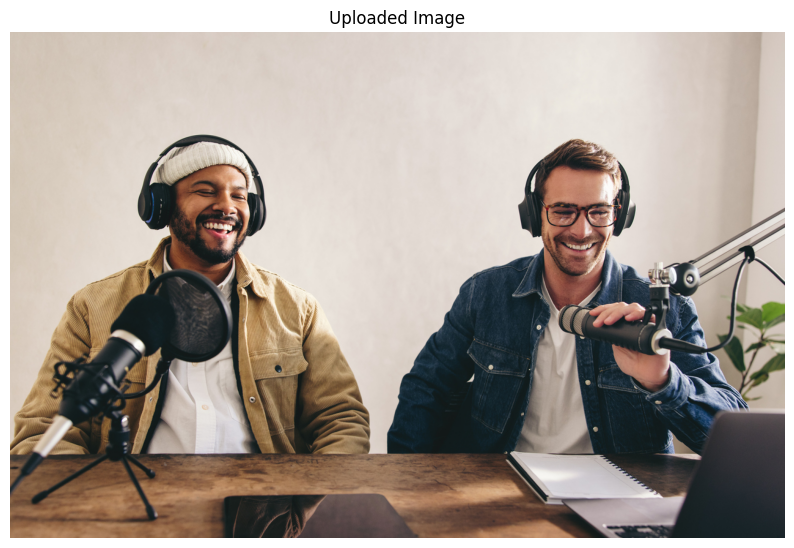

In [2]:
import os
import tempfile
import cv2 as cv
import numpy as np
import PIL.Image as Image
from google.colab import files
import matplotlib.pyplot as plt

# Variable for uploading files
image_path = ""
image_cv = None
image_pil = None
uploaded = files.upload()

for fn in uploaded.keys():
  print('- File "{name}" uploaded with length {length} bytes.'.format(
      name=fn, length=len(uploaded[fn])))

  # Save the uploaded file to a temporary location
  suffix = os.path.splitext(fn)[1] # Get extension
  with tempfile.NamedTemporaryFile(delete=False, suffix=suffix) as tmp_file:
    tmp_file.write(uploaded[fn])
    image_path = tmp_file.name

  try:
    # Load the image using OpenCV
    image_cv = cv.imread(image_path)
    # Load as PIL image
    image_pil = Image.fromarray(cv.cvtColor(image_cv, cv.COLOR_BGR2RGB))
  except Exception as X:
    print(f"[Error]: Could not load image '{fn}' with OpenCV!")

  # Display the image
  if image_pil is not None:
    plt.figure(figsize=(10, 10))
    plt.imshow(image_pil)
    plt.title(f"Uploaded Image")
    plt.axis('off')
    plt.show()

## **III. Calculate the Depth using 'Depth Pro'**

In [3]:
import torch
import depth_pro

# Prepare the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model and preprocessing transform
%cd ml-depth-pro
model, transform = depth_pro.create_model_and_transforms(
  device=device,
  precision=torch.half,
)
%cd ..

# Call the eval() function to prepare the model
model.eval()

/content/ml-depth-pro
/content


DepthPro(
  (encoder): DepthProEncoder(
    (patch_encoder): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): LayerScale()
          (drop_path1): Identity()
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp)

- Estimated focal length: 1515.3935546875


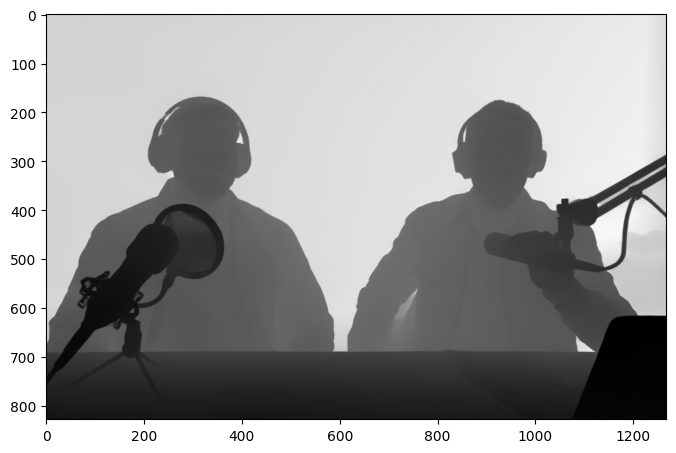

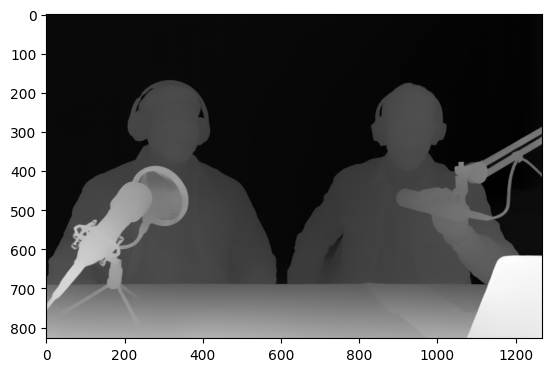

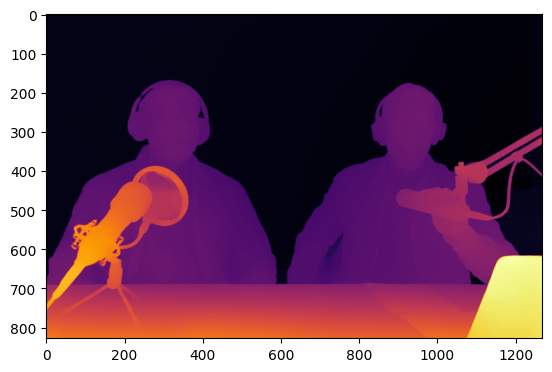

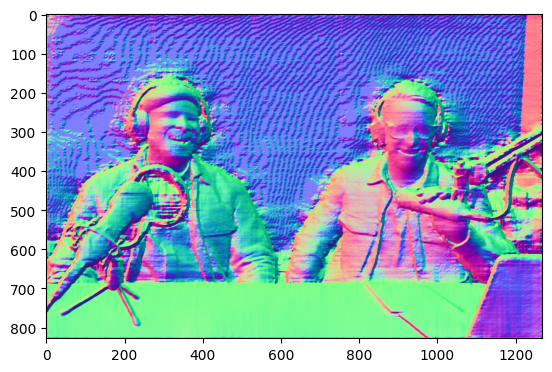

In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load image and focal length
image, _, f_px = depth_pro.load_rgb(image_path)

# Extract the depth and focal length.
prediction = model.infer(transform(image), f_px=f_px)
depth = prediction["depth"].detach().cpu().numpy().squeeze()

# Provide the checks with the focal lenth
if f_px is not None:
  print(f"- Estimated focal length (from exif): {f_px:0.2f}")
elif prediction["focallength_px"] is not None:
  # Get the real focal length values
  focallength_px = prediction["focallength_px"].detach().cpu().item()
  print(f"- Estimated focal length: {focallength_px}")

# ------------------ Raw Depth ---------------
max_depth_vizu = min(depth.max(), 1 / 0.1)
min_depth_vizu = max(depth.min(), 1 / 250)
depth_clipped = np.clip(depth, min_depth_vizu, max_depth_vizu)
depth_normalized = (depth_clipped - min_depth_vizu) / (max_depth_vizu - min_depth_vizu)
grayscale_depth = (depth_normalized * 255).astype(np.uint8)

# ------------------ Inverse Depth ---------------
inverse_depth = 1 / depth
max_invdepth_vizu = inverse_depth.max()
min_invdepth_vizu = inverse_depth.min()
inverse_depth_normalized = (inverse_depth - min_invdepth_vizu) / (max_invdepth_vizu - min_invdepth_vizu)
inverse_depth_grayscale = (inverse_depth_normalized * 255).astype(np.uint8)

# ------------------ Colored Depth ---------------
cmap = plt.get_cmap("inferno")
color_depth = (cmap(inverse_depth_normalized)[..., :3] * 255).astype(np.uint8)

# --------------- Surface Normal --------------
kernel_size = 7
grad_x = cv.Sobel(depth.astype(np.float32), cv.CV_32F, 1, 0, ksize = kernel_size)
grad_y = cv.Sobel(depth.astype(np.float32), cv.CV_32F, 0, 1, ksize = kernel_size)
z = np.full(grad_x.shape, 1)
normals = np.dstack((-grad_x, -grad_y, z))
normals_mag = np.linalg.norm(normals, axis= 2, keepdims=True)
with np.errstate(divide="ignore", invalid="ignore"):
  normals_normalized = normals / (normals_mag + 1e-5)
normals_normalized = np.nan_to_num(normals_normalized, nan = -1, posinf=-1, neginf=-1)
normal_from_depth = ((normals_normalized + 1) / 2 * 255).astype(np.uint8)

# --------------- Visualize --------------
plt.figure(figsize=(8, 8))
plt.imshow(grayscale_depth, cmap='gray')
plt.show()
plt.imshow(inverse_depth_grayscale, cmap='gray')
plt.show()
plt.imshow(color_depth, cmap='gray')
plt.show()
plt.imshow(normal_from_depth, cmap='gray')
plt.show()

## **IV. Depth Blur**

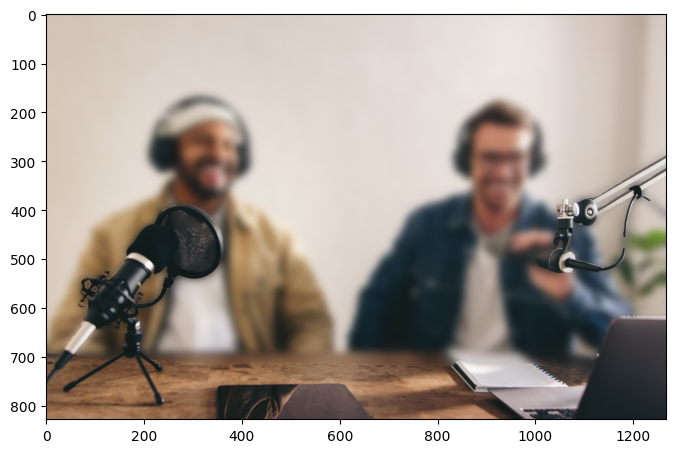

In [5]:
import cv2 as cv

# BGR to RGB
image_cv_rgb = cv.cvtColor(image_cv, cv.COLOR_BGR2RGB)

# Normalize depth map to range [0, 1]
depth_map_normalized = cv.normalize(grayscale_depth.astype(np.float32),
                                    None, 0, 1, cv.NORM_MINMAX)

# Convert normalized depth map back to uint8 (0-255 range)
depth_map_uint8 = (depth_map_normalized * 255).astype(np.uint8)

# Automatically infer focus range
focus_margin = 0.22
min_depth = np.min(depth_map_normalized)
focus_near = int(min_depth * 255)
focus_far = int((min_depth + focus_margin) * 255)

# Create a binary mask for the focus region
focus_mask = cv.inRange(depth_map_uint8, focus_near, focus_far)

# Apply Gaussian blur to the entire image
blurred_image = cv.GaussianBlur(image_cv_rgb, (51, 51), 0)

# Convert focus mask to 3 channels for blending
focus_mask_color = cv.merge([focus_mask, focus_mask, focus_mask])

# Blend images: Keep original where mask is white, blur otherwise
result = np.where(focus_mask_color == 255, image_cv_rgb, blurred_image)

# Visualize
plt.figure(figsize=(8, 8))
plt.imshow(result, cmap='gray')
plt.show()

## **V. Parallax Effect**

In [6]:
# Variables
fps = 60
frame_count = 300
displacement = 25

# Create a video writer for MP4
h, w, _ = image.shape
out = cv.VideoWriter('parallax_effect.mp4', cv.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

# Generate frames
for t in range(frame_count):
  # Calculate x and y displacement to create a smooth looping effect
  dx = displacement * np.sin(2 * np.pi * t / frame_count)
  dy = displacement * np.cos(2 * np.pi * t / frame_count)

  # Warp the image based on the depth map and displacement
  flow_x = depth_map_normalized * dx
  flow_y = depth_map_normalized * dy

  # Create a meshgrid for remapping
  x, y = np.meshgrid(np.arange(w), np.arange(h))
  map_x = (x + flow_x).astype(np.float32)
  map_y = (y + flow_y).astype(np.float32)

  # Remap the image
  warped_image = cv.remap(image, map_x, map_y, interpolation=cv.INTER_LINEAR, borderMode=cv.BORDER_REFLECT)

  # Debug: Ensure warped image is valid
  if t == 0:
    print(f"Warped Image Shape: {warped_image.shape}")
    print(f"Warped Image Dtype: {warped_image.dtype}")

  # Write the frame to the video
  out.write(warped_image)

# Release resources
out.release()

Warped Image Shape: (828, 1268, 3)
Warped Image Dtype: uint8


## **VI. Depth to Point Cloud**

In [ ]:
# pip install open3d==0.18.0
import open3d as o3d

# Get the height and width
height, width, _ = image_cv_rgb.shape
print(f"- Dimensions of the color image: {width} x {height}")

# Calculate the grid
x,y = np.meshgrid(np.arange(width), np.arange(height))
x = (x - width /2) / focallength_px
y = (y - height / 2) / focallength_px

# Calculate z-axis
z = np.array(grayscale_depth)

# Now, get the points
points = np.stack((np.multiply(x,z), np.multiply(y, z), z), axis = -1).reshape(-1, 3)
print(f"- Points shape: {points.shape}")

# Colors
colors = np.array(image_cv_rgb).reshape(-1, 3) / 255.0
print(f"- Colors shape: {colors.shape}")

# Create the point cloud
point_cloud = np.hstack((points, colors))

# Create an Open3D point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

# Save the 3D point cloud
os.makedirs("vis_point_cloud", exist_ok=True)
o3d.io.write_point_cloud(f'{os.path.join("vis_point_cloud", "satya.ply")}', pcd)

# Load in the point cloud created from OpenCV to compared to Open3D
pcd = o3d.io.read_point_cloud("vis_point_cloud/satya.ply")
# Flip it, otherwise the pointcloud will be upside down
pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
o3d.visualization.draw_geometries([pcd])

- Dimensions of the color image: 1268 x 828
- Points shape: (1049904, 3)
- Colors shape: (1049904, 3)
